# Dzonglish NMT — Full Pipeline
**A Neural Machine Translation Approach for Bidirectional Translation between English and Roman Dzongkha**

**Models:** Seq2Seq | Seq2Seq+Teacher Forcing | Seq2Seq+Attention | Transformer | MarianMT (x2)

**Metrics:** BLEU | METEOR | chrF | ROUGE-1 | ROUGE-2 | ROUGE-L

---
1. Runtime > Change runtime type > T4 GPU
2. Upload CSV to Google Drive
3. Update DATA_PATH in Cell 2
4. Runtime > Run all

In [ ]:
# Remove the existing directory
!rm -rf /content/drive

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [ ]:
# Cell 2: Configuration — UPDATE DATA_PATH
DATA_PATH      = '/content/drive/MyDrive/NLP_Notes/Project/dzonglish_dataset.csv'
OUTPUT_DIR     = '/content/drive/MyDrive/NMT_Results'
COL_EN         = 'english'
COL_DZ         = 'romanized'
EPOCHS_SCRATCH = 50
EPOCHS_MARIAN  = 30
BATCH_SIZE     = 32
SEED           = 42

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')

Output: /content/drive/MyDrive/NMT_Results


In [ ]:
# Cell 3: Install and imports
!pip install nltk rouge-score transformers sentencepiece -q

import re, math, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.translate.meteor_score import meteor_score as nltk_meteor
from rouge_score import rouge_scorer
from transformers import MarianMTModel, MarianTokenizer
warnings.filterwarnings('ignore')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

  Preparing metadata (setup.py) ... done
Device: cuda
GPU: Tesla T4


In [ ]:
# Cell 4: Preprocessing
# Only methods relevant to NMT on Dzonglish — nothing done just for the sake of it.

CONTRACTIONS = {
    "won't":"will not","can't":"cannot","i'm":"i am","i've":"i have",
    "i'll":"i will","i'd":"i would","you're":"you are","you've":"you have",
    "you'll":"you will","you'd":"you would","he's":"he is","he'll":"he will",
    "she's":"she is","she'll":"she will","it's":"it is","we're":"we are",
    "we've":"we have","we'll":"we will","they're":"they are","they've":"they have",
    "they'll":"they will","that's":"that is","there's":"there is",
    "isn't":"is not","aren't":"are not","wasn't":"was not","weren't":"were not",
    "hasn't":"has not","haven't":"have not","hadn't":"had not",
    "doesn't":"does not","don't":"do not","didn't":"did not",
    "wouldn't":"would not","shouldn't":"should not","couldn't":"could not",
    "mustn't":"must not","let's":"let us","what's":"what is",
    "who's":"who is","how's":"how is","where's":"where is",
}

def normalize_english(text):
    """
    1. Lowercase — reduces vocab, no semantic loss for NMT
    2. Expand contractions — helps tokenization
    3. Remove URLs/HTML — untranslatable noise
    4. Keep only valid chars — letters, digits, basic punctuation
    5. Normalize whitespace
    """
    text = str(text).lower().strip()
    for c, e in CONTRACTIONS.items():
        text = text.replace(c, e)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r"[^a-z0-9\s.,!?'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_dzonglish(text):
    """
    1. Lowercase — no standard casing in Dzonglish
    2. Remove URLs/HTML
    3. Keep letters and basic punctuation only
       (digits removed — digit-containing Dzonglish is usually mixed-language noise)
    4. Normalize whitespace
    """
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r"[^a-z\s.,!?'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def filter_pairs(df, col_en, col_dz, min_len=2, max_len=40):
    """
    Removes:
    - Empty rows after normalization
    - Identical source == target pairs (dataset errors)
    - Too-short (< 2 tokens) — not enough context
    - Too-long (> 40 tokens) — GPU memory and training noise
    - Exact duplicate pairs
    """
    n0 = len(df)
    df = df[df[col_en].str.strip() != ''].copy()
    df = df[df[col_dz].str.strip() != ''].copy()
    print(f'  After empty removal    : {len(df):>5}  (removed {n0-len(df)})')

    n1 = len(df)
    df = df[df[col_en] != df[col_dz]].copy()
    print(f'  After src==tgt removal : {len(df):>5}  (removed {n1-len(df)})')

    n2 = len(df)
    el = df[col_en].str.split().str.len()
    dl = df[col_dz].str.split().str.len()
    df = df[(el >= min_len) & (el <= max_len) & (dl >= min_len) & (dl <= max_len)].copy()
    print(f'  After length filter    : {len(df):>5}  (removed {n2-len(df)})')

    n3 = len(df)
    df = df.drop_duplicates(subset=[col_en, col_dz])
    print(f'  After deduplication   : {len(df):>5}  (removed {n3-len(df)})')
    return df.reset_index(drop=True)

print('Loading and preprocessing...')
df_raw = pd.read_csv(DATA_PATH).dropna(subset=[COL_EN, COL_DZ])
print(f'Raw pairs: {len(df_raw)}')
df_raw[COL_EN] = df_raw[COL_EN].apply(normalize_english)
df_raw[COL_DZ] = df_raw[COL_DZ].apply(normalize_dzonglish)
print('\nFiltering:')
df = filter_pairs(df_raw, COL_EN, COL_DZ)
print(f'\nFinal: {len(df)} pairs')
print('\nSamples:')
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f'  EN: {row[COL_EN]}')
    print(f'  DZ: {row[COL_DZ]}')
    print()

Loading and preprocessing...
Raw pairs: 3882

Filtering:
  After empty removal    :  3882  (removed 0)
  After src==tgt removal :  3869  (removed 13)
  After length filter    :  3823  (removed 46)
  After deduplication   :  3813  (removed 10)

Final: 3813 pairs

Samples:
  EN: watch the rear. i will watch the front.
  DZ: zhukha ta nga ghi dongkha ta wong

  EN: they are doctors.
  DZ: doctor dhu

  EN: he acted like a madman.
  DZ: kho tsagey zum beydey

  EN: it is in the garage.
  DZ: garage na yoe

  EN: i do not have medical training.
  DZ: nga lu so yi training mi



In [ ]:
# Cell 5: Stats, split, save
en_lens = [len(s.split()) for s in df[COL_EN]]
dz_lens = [len(s.split()) for s in df[COL_DZ]]
print('Dataset Statistics')
print(f'  Total pairs        : {len(df)}')
print(f'  English  avg/max   : {np.mean(en_lens):.1f} / {max(en_lens)} words')
print(f'  Dzonglish avg/max  : {np.mean(dz_lens):.1f} / {max(dz_lens)} words')

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n        = len(df)
train_df = df[:int(0.70*n)]
val_df   = df[int(0.70*n):int(0.85*n)]
test_df  = df[int(0.85*n):]
print(f'\nSplit  Train:{len(train_df)}  Val:{len(val_df)}  Test:{len(test_df)}')

train_df.to_csv(f'{OUTPUT_DIR}/split_train.csv', index=False)
val_df.to_csv(f'{OUTPUT_DIR}/split_val.csv',   index=False)
test_df.to_csv(f'{OUTPUT_DIR}/split_test.csv',  index=False)
print('Splits saved.')

Dataset Statistics
  Total pairs        : 3813
  English  avg/max   : 6.4 / 35 words
  Dzonglish avg/max  : 7.0 / 33 words

Split  Train:2669  Val:572  Test:572
Splits saved.


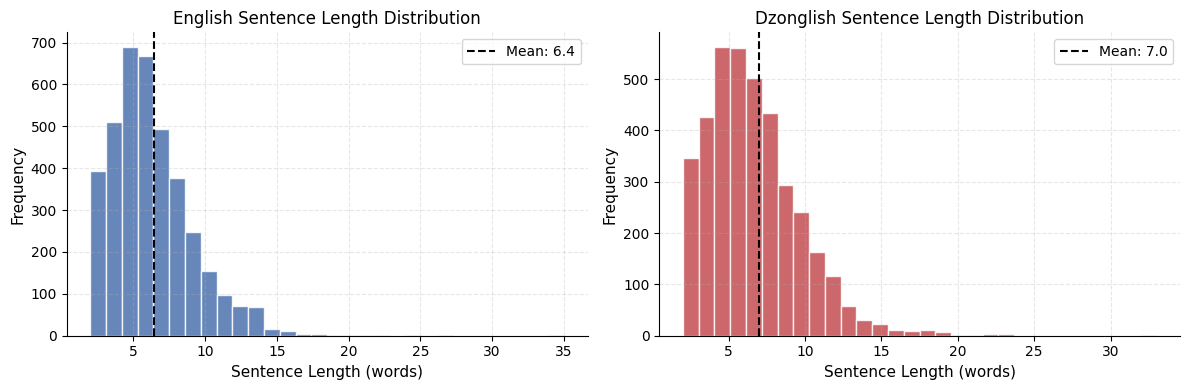

Saved: sentence_length_distribution.png


In [ ]:
# Cell 6: Sentence length distribution chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lens, lang, color in zip(axes, [en_lens, dz_lens],
                                  ['English','Dzonglish'], ['#4C72B0','#C44E52']):
    ax.hist(lens, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(np.mean(lens), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {np.mean(lens):.1f}')
    ax.set_xlabel('Sentence Length (words)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{lang} Sentence Length Distribution', fontsize=12)
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentence_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentence_length_distribution.png')

In [ ]:
# Cell 7: Vocabulary
class Vocabulary:
    def __init__(self, min_freq=1):
        self.stoi = {'<PAD>':0,'<SOS>':1,'<EOS>':2,'<UNK>':3}
        self.itos = {v:k for k,v in self.stoi.items()}
        self.min_freq = min_freq

    def build(self, sentences):
        freq = Counter(t for s in sentences for t in s.split())
        for w, c in sorted(freq.items()):
            if c >= self.min_freq and w not in self.stoi:
                i = len(self.stoi)
                self.stoi[w] = i
                self.itos[i] = w

    def encode(self, s): return [self.stoi.get(t,3) for t in s.split()]
    def __len__(self):   return len(self.stoi)

en_vocab = Vocabulary()
dz_vocab = Vocabulary()
en_vocab.build(list(train_df[COL_EN]))
dz_vocab.build(list(train_df[COL_DZ]))
print(f'English vocab size   : {len(en_vocab)}')
print(f'Dzonglish vocab size : {len(dz_vocab)}')

English vocab size   : 3407
Dzonglish vocab size : 3311


In [ ]:
# Cell 8: Dataset and DataLoader
class TranslationDataset(Dataset):
    def __init__(self, src, tgt, sv, tv, max_len=40):
        self.pairs = []
        for s, t in zip(src, tgt):
            se = [1] + sv.encode(s)[:max_len] + [2]
            te = [1] + tv.encode(t)[:max_len] + [2]
            self.pairs.append((torch.tensor(se), torch.tensor(te)))
    def __len__(self):        return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]

def collate_fn(batch):
    s, t = zip(*batch)
    return (nn.utils.rnn.pad_sequence(s, batch_first=True, padding_value=0),
            nn.utils.rnn.pad_sequence(t, batch_first=True, padding_value=0))

print('Dataset class ready.')

Dataset class ready.


In [ ]:
# Cell 9: Model architectures
class Encoder(nn.Module):
    def __init__(self, vsz, emb, hid, nl, dr):
        super().__init__()
        self.emb = nn.Embedding(vsz, emb, padding_idx=0)
        self.rnn = nn.GRU(emb, hid, nl, dropout=dr if nl>1 else 0, batch_first=True)
        self.drop = nn.Dropout(dr)
    def forward(self, x): return self.rnn(self.drop(self.emb(x)))

class Decoder(nn.Module):
    def __init__(self, vsz, emb, hid, nl, dr):
        super().__init__()
        self.emb  = nn.Embedding(vsz, emb, padding_idx=0)
        self.rnn  = nn.GRU(emb, hid, nl, dropout=dr if nl>1 else 0, batch_first=True)
        self.fc   = nn.Linear(hid, vsz)
        self.drop = nn.Dropout(dr)
    def forward(self, x, h):
        o, h = self.rnn(self.drop(self.emb(x.unsqueeze(1))), h)
        return self.fc(o.squeeze(1)), h

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encoder = enc
        self.decoder = dec
    def forward(self, src, tgt, teacher_forcing_ratio=0.0):
        B, T = tgt.shape
        V    = self.decoder.fc.out_features
        outs = torch.zeros(B, T, V).to(device)
        _, h = self.encoder(src)
        inp  = tgt[:,0]
        for t in range(1, T):
            o, h = self.decoder(inp, h)
            outs[:,t] = o
            inp = tgt[:,t] if random.random() < teacher_forcing_ratio else o.argmax(1)
        return outs

class Attention(nn.Module):
    def __init__(self, hid):
        super().__init__()
        self.a = nn.Linear(hid*2, hid)
        self.v = nn.Linear(hid, 1, bias=False)
    def forward(self, h, enc):
        L   = enc.shape[1]
        hr  = h[-1].unsqueeze(1).repeat(1,L,1)
        e   = torch.tanh(self.a(torch.cat([hr,enc],dim=-1)))
        atw = torch.softmax(self.v(e).squeeze(-1), dim=1)
        return torch.bmm(atw.unsqueeze(1), enc).squeeze(1)

class DecoderAttn(nn.Module):
    def __init__(self, vsz, emb, hid, nl, dr):
        super().__init__()
        self.emb  = nn.Embedding(vsz, emb, padding_idx=0)
        self.attn = Attention(hid)
        self.rnn  = nn.GRU(emb+hid, hid, nl, dropout=dr if nl>1 else 0, batch_first=False)
        self.fc   = nn.Linear(hid*2+emb, vsz)
        self.drop = nn.Dropout(dr)
    def forward(self, x, h, enc):
        emb = self.drop(self.emb(x.unsqueeze(0)))
        ctx = self.attn(h, enc)
        o, h = self.rnn(torch.cat([emb, ctx.unsqueeze(0)], dim=-1), h)
        return self.fc(torch.cat([o.squeeze(0), ctx, emb.squeeze(0)], dim=-1)), h

class Seq2SeqAttn(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encoder = enc
        self.decoder = dec
    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B, T   = tgt.shape
        V      = self.decoder.fc.out_features
        outs   = torch.zeros(B, T, V).to(device)
        eo, h  = self.encoder(src)
        inp    = tgt[:,0]
        for t in range(1, T):
            o, h = self.decoder(inp, h, eo)
            outs[:,t] = o
            inp = tgt[:,t] if random.random() < teacher_forcing_ratio else o.argmax(1)
        return outs

class PosEnc(nn.Module):
    def __init__(self, d, mxl=512, dr=0.1):
        super().__init__()
        self.drop = nn.Dropout(dr)
        pe = torch.zeros(mxl, d)
        p  = torch.arange(0, mxl).unsqueeze(1).float()
        dv = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(p * dv)
        pe[:, 1::2] = torch.cos(p * dv)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return self.drop(x + self.pe[:, :x.size(1)])

class TFModel(nn.Module):
    def __init__(self, sv, tv, d, nh, ne, nd, ff, dr):
        super().__init__()
        self.se  = nn.Embedding(sv, d, padding_idx=0)
        self.te  = nn.Embedding(tv, d, padding_idx=0)
      # CORRECT - replace with this
        self.sp  = PosEnc(d, dr=dr)
        self.tp  = PosEnc(d, dr=dr)
        self.tf  = nn.Transformer(d_model=d, nhead=nh, num_encoder_layers=ne,
                                  num_decoder_layers=nd, dim_feedforward=ff,
                                  dropout=dr, batch_first=True)
        self.fc  = nn.Linear(d, tv)
        self.sc  = math.sqrt(d)
    def forward(self, src, tgt):
        tm  = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(device)
        out = self.tf(self.sp(self.se(src)*self.sc), self.tp(self.te(tgt)*self.sc),
                      tgt_mask=tm, src_key_padding_mask=(src==0),
                      tgt_key_padding_mask=(tgt==0), memory_key_padding_mask=(src==0))
        return self.fc(out)

class NoamLR:
    def __init__(self, opt, d, warmup=400):
        self.opt=opt; self.d=d; self.w=warmup; self.s=0
    def step(self):
        self.s += 1
        lr = self.d**-0.5 * min(self.s**-0.5, self.s*self.w**-1.5)
        for p in self.opt.param_groups: p['lr'] = lr
    def get_lr(self): return self.opt.param_groups[0]['lr']

print('All architectures defined.')

All architectures defined.


In [ ]:
# Cell 10: Evaluation metrics
def compute_bleu(hyps, refs):
    if not hyps: return 0.0
    cl=Counter(); tl=Counter(); hl=rl=0
    for h, r in zip(hyps, refs):
        ht=h.split(); rt=r.split(); hl+=len(ht); rl+=len(rt)
        for n in range(1,5):
            hg=Counter([tuple(ht[i:i+n]) for i in range(len(ht)-n+1)])
            rg=Counter([tuple(rt[i:i+n]) for i in range(len(rt)-n+1)])
            for g,c in hg.items(): cl[n]+=min(c,rg.get(g,0)); tl[n]+=c
    pr=[cl[n]/tl[n] if tl[n] else 0 for n in range(1,5)]
    if any(p==0 for p in pr): return 0.0
    bp=1.0 if hl>=rl else math.exp(1-rl/hl)
    return round(bp*math.exp(sum(math.log(p) for p in pr)/4)*100, 2)

def compute_meteor(hyps, refs):
    sc=[nltk_meteor([r.split()],h.split()) for h,r in zip(hyps,refs) if h and r]
    return round(float(np.mean(sc))*100, 2) if sc else 0.0

def compute_chrf(hyps, refs, b=2):
    def cng(t,n): t=t.replace(' ',''); return Counter([t[i:i+n] for i in range(len(t)-n+1)])
    tp=tr=cnt=0
    for h,r in zip(hyps,refs):
        if not h or not r: continue
        ps,rs=[],[]
        for n in range(1,7):
            hg=cng(h,n); rg=cng(r,n)
            th=sum(hg.values()); tr_=sum(rg.values())
            m=sum(min(hg[g],rg[g]) for g in hg)
            ps.append(m/th if th else 0); rs.append(m/tr_ if tr_ else 0)
        p,r_=np.mean(ps),np.mean(rs)
        if p+r_==0: continue
        tp+=p; tr+=r_; cnt+=1
    if cnt==0: return 0.0
    ap,ar=tp/cnt,tr/cnt
    if ap+ar==0: return 0.0
    return round((1+b**2)*ap*ar/(b**2*ap+ar)*100, 2)

def compute_rouge(hyps, refs):
    sc=rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'],use_stemmer=False)
    r1=r2=rl=cnt=0
    for h,r in zip(hyps,refs):
        if not h or not r: continue
        s=sc.score(r,h); r1+=s['rouge1'].fmeasure
        r2+=s['rouge2'].fmeasure; rl+=s['rougeL'].fmeasure; cnt+=1
    if cnt==0: return 0.0,0.0,0.0
    return round(r1/cnt*100,2),round(r2/cnt*100,2),round(rl/cnt*100,2)

def all_metrics(hyps, refs):
    r1,r2,rl=compute_rouge(hyps,refs)
    return {'bleu':compute_bleu(hyps,refs),'meteor':compute_meteor(hyps,refs),
            'chrf':compute_chrf(hyps,refs),'rouge1':r1,'rouge2':r2,'rougeL':rl}

print('Metrics defined.')

Metrics defined.


In [ ]:
# Cell 11: Training helpers
def dtok(tensor, vocab):
    return ' '.join([vocab.itos.get(t.item(),'') for t in tensor if t.item() not in (0,1,2)])

def translate(model, st, tv, max_len=40, is_tf=False):
    model.eval()
    with torch.no_grad():
        src=st.unsqueeze(0).to(device)
        sos=tv.stoi['<SOS>']; eos=tv.stoi['<EOS>']
        if is_tf:
            tgt=torch.tensor([[sos]]).to(device)
            for _ in range(max_len):
                o=model(src,tgt); nxt=o[:,-1,:].argmax(-1)
                tgt=torch.cat([tgt,nxt.unsqueeze(0)],dim=1)
                if nxt.item()==eos: break
            tokens=tgt[0,1:].tolist()
        else:
            eo,h=model.encoder(src)
            inp=torch.tensor([sos]).to(device); tokens=[]
            for _ in range(max_len):
                if isinstance(model,Seq2SeqAttn): o,h=model.decoder(inp,h,eo)
                else: o,h=model.decoder(inp,h)
                p=o.argmax(-1); tokens.append(p.item())
                if p.item()==eos: break
                inp=p
        return ' '.join([tv.itos.get(t,'') for t in tokens if t not in (0,1,2,eos)])

def train_ep(model, loader, opt, crit, tfr, is_tf, noam=None):
    model.train(); tl=co=tot=0
    for src,tgt in loader:
        src,tgt=src.to(device),tgt.to(device); opt.zero_grad()
        if is_tf:
            o=model(src,tgt[:,:-1]).reshape(-1,model.fc.out_features)
            t=tgt[:,1:].reshape(-1)
        else:
            o=model(src,tgt,teacher_forcing_ratio=tfr)
            o=o[:,1:].reshape(-1,o.size(-1)); t=tgt[:,1:].reshape(-1)
        msk=t!=0; loss=crit(o[msk],t[msk]); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step()
        if noam: noam.step()
        tl+=loss.item(); co+=(o[msk].argmax(-1)==t[msk]).sum().item(); tot+=msk.sum().item()
    return tl/len(loader), co/tot*100

def eval_ep(model, loader, crit, is_tf):
    model.eval(); vl=co=tot=0
    with torch.no_grad():
        for src,tgt in loader:
            src,tgt=src.to(device),tgt.to(device)
            if is_tf:
                o=model(src,tgt[:,:-1]).reshape(-1,model.fc.out_features)
                t=tgt[:,1:].reshape(-1)
            else:
                o=model(src,tgt,teacher_forcing_ratio=0.0)
                o=o[:,1:].reshape(-1,o.size(-1)); t=tgt[:,1:].reshape(-1)
            msk=t!=0; vl+=crit(o[msk],t[msk]).item()
            co+=(o[msk].argmax(-1)==t[msk]).sum().item(); tot+=msk.sum().item()
    return vl/len(loader), co/tot*100

print('Helpers defined.')

Helpers defined.


In [ ]:
# Cell 12: Train 4 from-scratch models (both directions)
EMB=128; HID=256; NL=1; DR=0.4; LR=0.0005

DIRECTIONS = [
    ('English to Dzonglish', en_vocab, dz_vocab, COL_EN, COL_DZ),
    ('Dzonglish to English', dz_vocab, en_vocab, COL_DZ, COL_EN),
]
CONFIGS = [
    ('Seq2Seq',                {'tf':0.0,'attn':False,'is_tf':False}),
    ('Seq2Seq+Teacher Forcing',{'tf':0.5,'attn':False,'is_tf':False}),
    ('Seq2Seq+Attention',      {'tf':0.5,'attn':True, 'is_tf':False}),
    ('Transformer',            {'tf':0.0,'attn':False,'is_tf':True }),
]

all_results = {'English to Dzonglish':{},'Dzonglish to English':{}}

for dname, sv, tv, sc, tc in DIRECTIONS:
    print(f'\n{"="*60}\n  {dname}\n{"="*60}')
    trd=TranslationDataset(train_df[sc],train_df[tc],sv,tv)
    vad=TranslationDataset(val_df[sc],  val_df[tc],  sv,tv)
    ted=TranslationDataset(test_df[sc], test_df[tc], sv,tv)
    trl=DataLoader(trd,BATCH_SIZE,shuffle=True, collate_fn=collate_fn)
    val=DataLoader(vad,BATCH_SIZE,shuffle=False,collate_fn=collate_fn)

    for mname, cfg in CONFIGS:
        print(f'\n  [{mname}]')
        if cfg['is_tf']:
            model=TFModel(len(sv),len(tv),128,4,2,2,256,DR).to(device)
            opt=optim.Adam(model.parameters(),lr=0.0,betas=(0.9,0.98),eps=1e-9)
            noam=NoamLR(opt,128,400); sched=None
        elif cfg['attn']:
            enc=Encoder(len(sv),EMB,HID,NL,DR).to(device)
            dec=DecoderAttn(len(tv),EMB,HID,NL,DR).to(device)
            model=Seq2SeqAttn(enc,dec).to(device)
            opt=optim.Adam(model.parameters(),lr=LR)
            noam=None; sched=optim.lr_scheduler.ReduceLROnPlateau(opt,patience=5,factor=0.5)
        else:
            enc=Encoder(len(sv),EMB,HID,NL,DR).to(device)
            dec=Decoder(len(tv),EMB,HID,NL,DR).to(device)
            model=Seq2Seq(enc,dec).to(device)
            opt=optim.Adam(model.parameters(),lr=LR)
            noam=None; sched=optim.lr_scheduler.ReduceLROnPlateau(opt,patience=5,factor=0.5)

        crit=nn.CrossEntropyLoss(ignore_index=0,label_smoothing=0.1)
        hist={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
        bvl=float('inf')
        key=f"{dname[:2]}_{mname.replace('+','').replace(' ','')}"
        sp=f'{OUTPUT_DIR}/best_{key}.pt'

        for ep in range(1,EPOCHS_SCRATCH+1):
            tl,ta=train_ep(model,trl,opt,crit,cfg['tf'],cfg['is_tf'],noam)
            vl,va=eval_ep(model,val,crit,cfg['is_tf'])
            if sched: sched.step(vl)
            hist['train_loss'].append(round(tl,6)); hist['val_loss'].append(round(vl,6))
            hist['train_acc'].append(round(ta,2));  hist['val_acc'].append(round(va,2))
            if vl<bvl: bvl=vl; torch.save(model.state_dict(),sp)
            if ep%10==0: print(f'  Ep {ep:3d} | TL:{tl:.4f} VL:{vl:.4f} VA:{va:.2f}%')

        model.load_state_dict(torch.load(sp))
        hyps=[translate(model,st,tv,is_tf=cfg['is_tf']) for st,_ in ted.pairs]
        refs=[dtok(tt,tv) for _,tt in ted.pairs]
        met=all_metrics(hyps,refs)
        bi=hist['val_loss'].index(min(hist['val_loss']))
        print(f'  BLEU:{met["bleu"]:.2f} METEOR:{met["meteor"]:.2f} chrF:{met["chrf"]:.2f} R1:{met["rouge1"]:.2f}')

        samps=[]
        print('  Samples:')
        for i in range(min(3,len(ted.pairs))):
            st,tt=ted.pairs[i]
            inp=dtok(st,sv); act=dtok(tt,tv)
            prd=translate(model,st,tv,is_tf=cfg['is_tf'])
            print(f'    IN :{inp}\n    ACT:{act}\n    PRD:{prd}')
            samps.append({'input':inp,'actual':act,'pred':prd})

        all_results[dname][mname]={
            'train_loss':hist['train_loss'],'val_loss':hist['val_loss'],
            'train_acc':hist['train_acc'],'val_acc':hist['val_acc'],
            'best_train_loss':round(hist['train_loss'][bi],6),
            'best_val_loss':round(hist['val_loss'][bi],6),
            'best_val_acc':round(hist['val_acc'][bi],2),
            **met,'sample_translations':samps}

print('\nFrom-scratch training complete.')


  English to Dzonglish

  [Seq2Seq]
  Ep  10 | TL:5.4646 VL:5.8978 VA:20.96%
  Ep  20 | TL:4.9977 VL:5.9300 VA:21.18%
  Ep  30 | TL:4.8277 VL:5.9496 VA:21.09%
  Ep  40 | TL:4.7739 VL:5.9572 VA:21.18%
  Ep  50 | TL:4.7603 VL:5.9591 VA:21.14%
  BLEU:0.00 METEOR:7.77 chrF:11.17 R1:16.46
  Samples:
    IN :we won.
    ACT:gey cc nga chey
    PRD:nga gi na na
    IN :tashi will come.
    ACT:tashi nga wong
    PRD:tashi gi gi gi gi gi
    IN :whose house is this?
    ACT:ga gi chim mo
    PRD:ani gi dhi dhi

  [Seq2Seq+Teacher Forcing]
  Ep  10 | TL:5.3974 VL:5.9359 VA:20.63%
  Ep  20 | TL:4.9557 VL:5.9682 VA:20.96%
  Ep  30 | TL:4.8084 VL:5.9825 VA:20.85%
  Ep  40 | TL:4.7638 VL:5.9856 VA:20.96%
  Ep  50 | TL:4.7380 VL:5.9916 VA:20.90%
  BLEU:0.00 METEOR:7.54 chrF:10.52 R1:15.10
  Samples:
    IN :we won.
    ACT:gey cc nga chey
    PRD:nga chay na bay
    IN :tashi will come.
    ACT:tashi nga wong
    PRD:tashi gi gi gi gi gi lu
    IN :whose house is this?
    ACT:ga gi chim mo
    PRD

In [ ]:
# Cell 13: MarianMT helpers
class MarianDS(Dataset):
    def __init__(self, src, tgt, tok, mx=64):
        e=tok(list(src),text_target=list(tgt),max_length=mx,
              truncation=True,padding='max_length',return_tensors='pt')
        lb=e['labels'].clone(); lb[lb==tok.pad_token_id]=-100; e['labels']=lb
        self.e=e
    def __len__(self): return len(self.e['input_ids'])
    def __getitem__(self,i): return {k:v[i] for k,v in self.e.items()}

def train_marian(model, tok, trds, vads, sp, epochs=30, bs=16, lr=5e-5):
    tl=DataLoader(trds,bs,shuffle=True, num_workers=2,pin_memory=True)
    vl=DataLoader(vads,bs,shuffle=False,num_workers=2,pin_memory=True)
    opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=0.01)
    sch=optim.lr_scheduler.OneCycleLR(opt,max_lr=lr,steps_per_epoch=len(tl),
                                       epochs=epochs,pct_start=0.1)
    bvl=float('inf'); hist={'train_loss':[],'val_loss':[]}
    for ep in range(1,epochs+1):
        model.train(); tls=0
        for b in tl:
            b={k:v.to(device) for k,v in b.items()}; opt.zero_grad()
            loss=model(**b).loss; loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); sch.step(); tls+=loss.item()
        tls/=len(tl)
        model.eval(); vls=0
        with torch.no_grad():
            for b in vl:
                b={k:v.to(device) for k,v in b.items()}; vls+=model(**b).loss.item()
        vls/=len(vl)
        hist['train_loss'].append(round(tls,6)); hist['val_loss'].append(round(vls,6))
        if vls<bvl: bvl=vls; model.save_pretrained(sp); tok.save_pretrained(sp)
        if ep%5==0: print(f'  Ep {ep:3d} | TL:{tls:.4f} VL:{vls:.4f}')
    print(f'  Best VL: {bvl:.6f}')
    return hist, bvl

def eval_marian(model, tok, src_texts, tgt_texts, mx=64, bs=32):
    model.eval(); hyps=[]; refs=list(tgt_texts); sl=list(src_texts)
    for i in range(0,len(sl),bs):
        inp=tok(sl[i:i+bs],return_tensors='pt',max_length=mx,
                truncation=True,padding=True).to(device)
        with torch.no_grad():
            out=model.generate(**inp,max_new_tokens=64,num_beams=4,early_stopping=True)
        hyps.extend(tok.batch_decode(out,skip_special_tokens=True))
    met=all_metrics(hyps,refs)
    print(f'  BLEU:{met["bleu"]:.2f} METEOR:{met["meteor"]:.2f} chrF:{met["chrf"]:.2f} R1:{met["rouge1"]:.2f}')
    samps=[]
    print('  Samples:')
    for i in range(min(3,len(sl))):
        print(f'    IN :{sl[i]}\n    ACT:{refs[i]}\n    PRD:{hyps[i]}')
        samps.append({'input':sl[i],'actual':refs[i],'pred':hyps[i]})
    return met, hyps, samps

print('MarianMT helpers defined.')

MarianMT helpers defined.


In [ ]:
# Cell 14: MarianMT English -> Dzonglish (opus-mt-en-mul)
print('='*60)
print('  MarianMT: English to Dzonglish  (opus-mt-en-mul)')
print('='*60)
ENMUL='Helsinki-NLP/opus-mt-en-mul'; SP_EN=f'{OUTPUT_DIR}/marian_en_dz'
tok_en=MarianTokenizer.from_pretrained(ENMUL)
mod_en=MarianMTModel.from_pretrained(ENMUL).to(device)
print(f'Params: {sum(p.numel() for p in mod_en.parameters())/1e6:.1f}M')
tr_en=MarianDS(train_df[COL_EN],train_df[COL_DZ],tok_en)
va_en=MarianDS(val_df[COL_EN],  val_df[COL_DZ],  tok_en)
hist_en, bvl_en=train_marian(mod_en,tok_en,tr_en,va_en,SP_EN,EPOCHS_MARIAN,16,5e-5)
mod_en=MarianMTModel.from_pretrained(SP_EN).to(device)
met_en,hyps_en,samp_en=eval_marian(mod_en,tok_en,test_df[COL_EN],test_df[COL_DZ])
all_results['English to Dzonglish']['MarianMT (en-mul)']={**{
    'train_loss':hist_en['train_loss'],'val_loss':hist_en['val_loss'],
    'train_acc':[],'val_acc':[],'best_train_loss':round(hist_en['train_loss'][-1],6),
    'best_val_loss':round(bvl_en,6),'best_val_acc':0.0},
    **met_en,'sample_translations':samp_en}
print('Done.')

  MarianMT: English to Dzonglish  (opus-mt-en-mul)


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/790k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/707k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Ep   5 | TL:2.4592 VL:3.0786
  Ep  10 | TL:0.9389 VL:3.5648
  Ep  15 | TL:0.3211 VL:4.0524
  Ep  20 | TL:0.1372 VL:4.2861
  Ep  25 | TL:0.0812 VL:4.4149
  Ep  30 | TL:0.0722 VL:4.4389
  Best VL: 3.078624


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  BLEU:5.24 METEOR:21.29 chrF:29.82 R1:32.05
  Samples:
    IN :we won.
    ACT:gey cc nga chey
    PRD:we gay
    IN :tashi will come.
    ACT:tashi nga wong
    PRD:tashi wong
    IN :whose house is this?
    ACT:ga gi chim mo
    PRD:ani chim gagi mo
Done.


In [ ]:
# Cell 15: MarianMT Dzonglish -> English (opus-mt-mul-en)
print('='*60)
print('  MarianMT: Dzonglish to English  (opus-mt-mul-en)')
print('='*60)
MULEN='Helsinki-NLP/opus-mt-mul-en'; SP_DZ=f'{OUTPUT_DIR}/marian_dz_en'
tok_dz=MarianTokenizer.from_pretrained(MULEN)
mod_dz=MarianMTModel.from_pretrained(MULEN).to(device)
print(f'Params: {sum(p.numel() for p in mod_dz.parameters())/1e6:.1f}M')
tr_dz=MarianDS(train_df[COL_DZ],train_df[COL_EN],tok_dz)
va_dz=MarianDS(val_df[COL_DZ],  val_df[COL_EN],  tok_dz)
hist_dz, bvl_dz=train_marian(mod_dz,tok_dz,tr_dz,va_dz,SP_DZ,EPOCHS_MARIAN,16,5e-5)
mod_dz=MarianMTModel.from_pretrained(SP_DZ).to(device)
met_dz,hyps_dz,samp_dz=eval_marian(mod_dz,tok_dz,test_df[COL_DZ],test_df[COL_EN])
all_results['Dzonglish to English']['MarianMT (mul-en)']={**{
    'train_loss':hist_dz['train_loss'],'val_loss':hist_dz['val_loss'],
    'train_acc':[],'val_acc':[],'best_train_loss':round(hist_dz['train_loss'][-1],6),
    'best_val_loss':round(bvl_dz,6),'best_val_acc':0.0},
    **met_dz,'sample_translations':samp_dz}
print('Done.')

  MarianMT: Dzonglish to English  (opus-mt-mul-en)


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/707k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/791k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Ep   5 | TL:1.1868 VL:2.5051
  Ep  10 | TL:0.2557 VL:3.0992
  Ep  15 | TL:0.0684 VL:3.4033
  Ep  20 | TL:0.0223 VL:3.6630
  Ep  25 | TL:0.0101 VL:3.7356
  Ep  30 | TL:0.0070 VL:3.7572
  Best VL: 2.453242


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  BLEU:3.59 METEOR:17.21 chrF:21.17 R1:27.11
  Samples:
    IN :gey cc nga chey
    ACT:we won.
    PRD:we are all set.
    IN :tashi nga wong
    ACT:tashi will come.
    PRD:i am tashi.
    IN :ga gi chim mo
    ACT:whose house is this?
    PRD:what is it?
Done.


In [ ]:
# Cell 16: Save JSON and print final summary
with open(f'{OUTPUT_DIR}/nmt_results.json','w') as f:
    json.dump(all_results,f,indent=2)
print(f'Saved: {OUTPUT_DIR}/nmt_results.json')

print('\n'+'='*92)
print('FINAL RESULTS SUMMARY')
print('='*92)
for dn, dr in all_results.items():
    print(f'\n{dn}')
    print(f'{"Model":<35} {"BLEU":>7} {"METEOR":>8} {"chrF":>7} {"R-1":>7} {"R-2":>7} {"R-L":>7} {"ValLoss":>10}')
    print('-'*92)
    for mn,m in dr.items():
        print(f'{mn:<35} {m["bleu"]:>7.2f} {m["meteor"]:>8.2f} {m["chrf"]:>7.2f} '
              f'{m["rouge1"]:>7.2f} {m["rouge2"]:>7.2f} {m["rougeL"]:>7.2f} {m["best_val_loss"]:>10.6f}')
print('\nCopy this table + all PNGs + nmt_results.json and send to Claude.')

Saved: /content/drive/MyDrive/NMT_Results/nmt_results.json

FINAL RESULTS SUMMARY

English to Dzonglish
Model                                  BLEU   METEOR    chrF     R-1     R-2     R-L    ValLoss
--------------------------------------------------------------------------------------------
Seq2Seq                                0.00     7.77   11.17   16.46    2.20   16.16   5.893490
Seq2Seq+Teacher Forcing                0.00     7.54   10.52   15.10    2.01   14.58   5.924707
Seq2Seq+Attention                      0.00     9.58   12.20   18.82    3.24   18.50   5.887773
Transformer                            0.00     3.95    4.90    3.08    0.40    3.06   6.074429
MarianMT (en-mul)                      5.24    21.29   29.82   32.05    9.28   30.27   3.078624

Dzonglish to English
Model                                  BLEU   METEOR    chrF     R-1     R-2     R-L    ValLoss
--------------------------------------------------------------------------------------------
Seq2Seq         

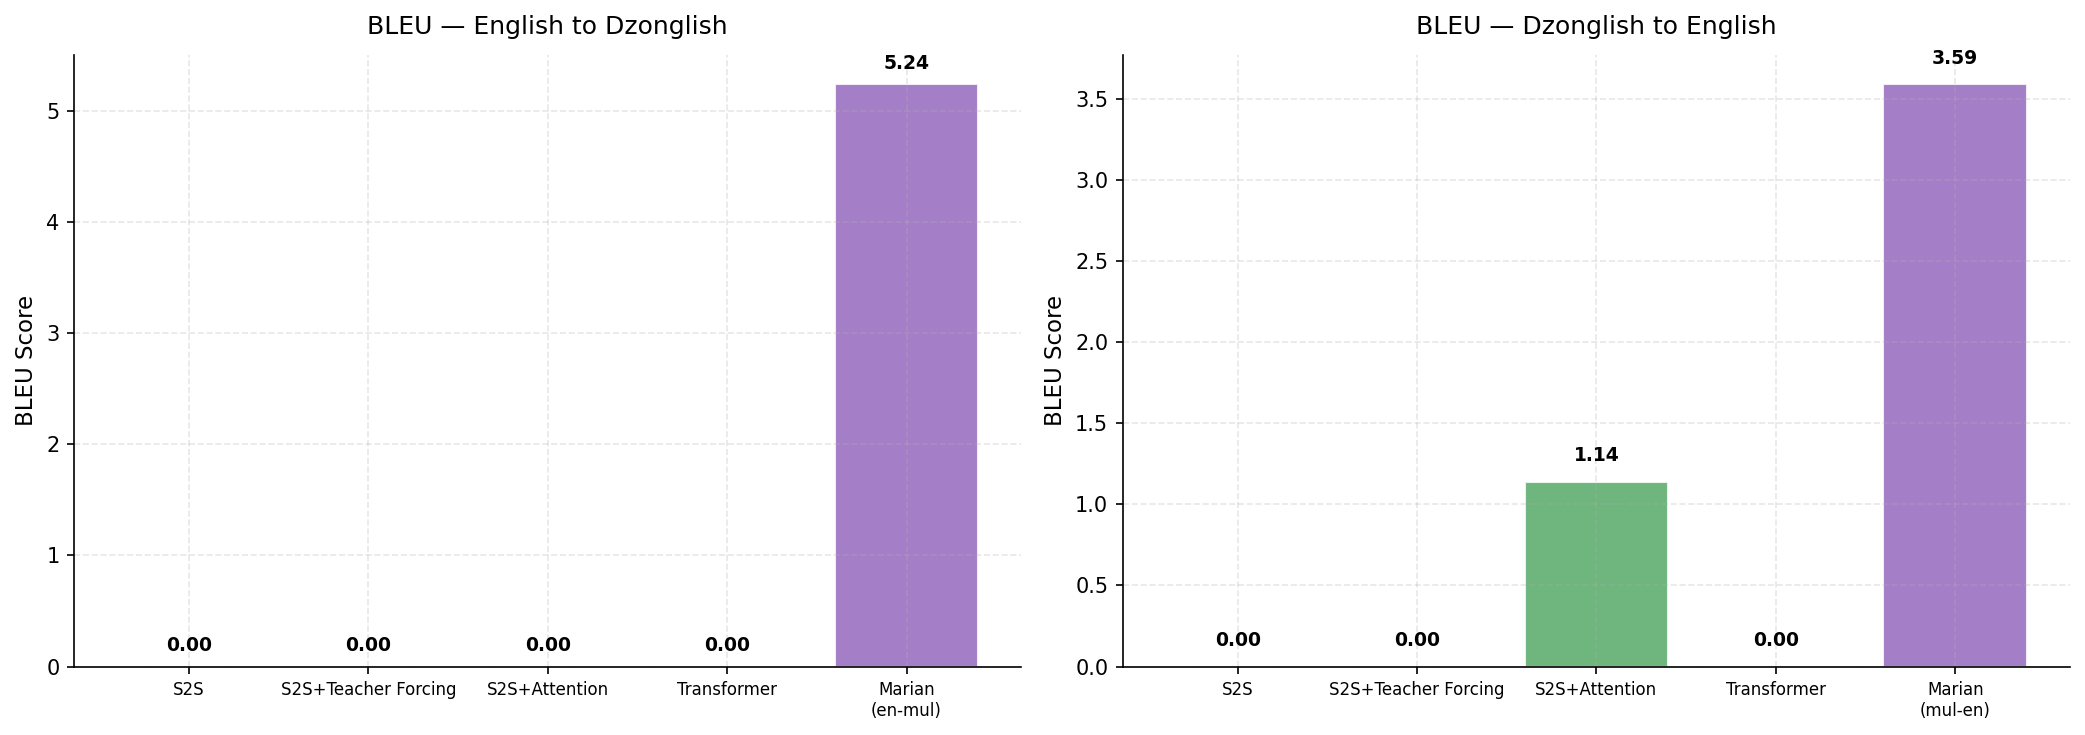

Saved: bleu_all_models.png


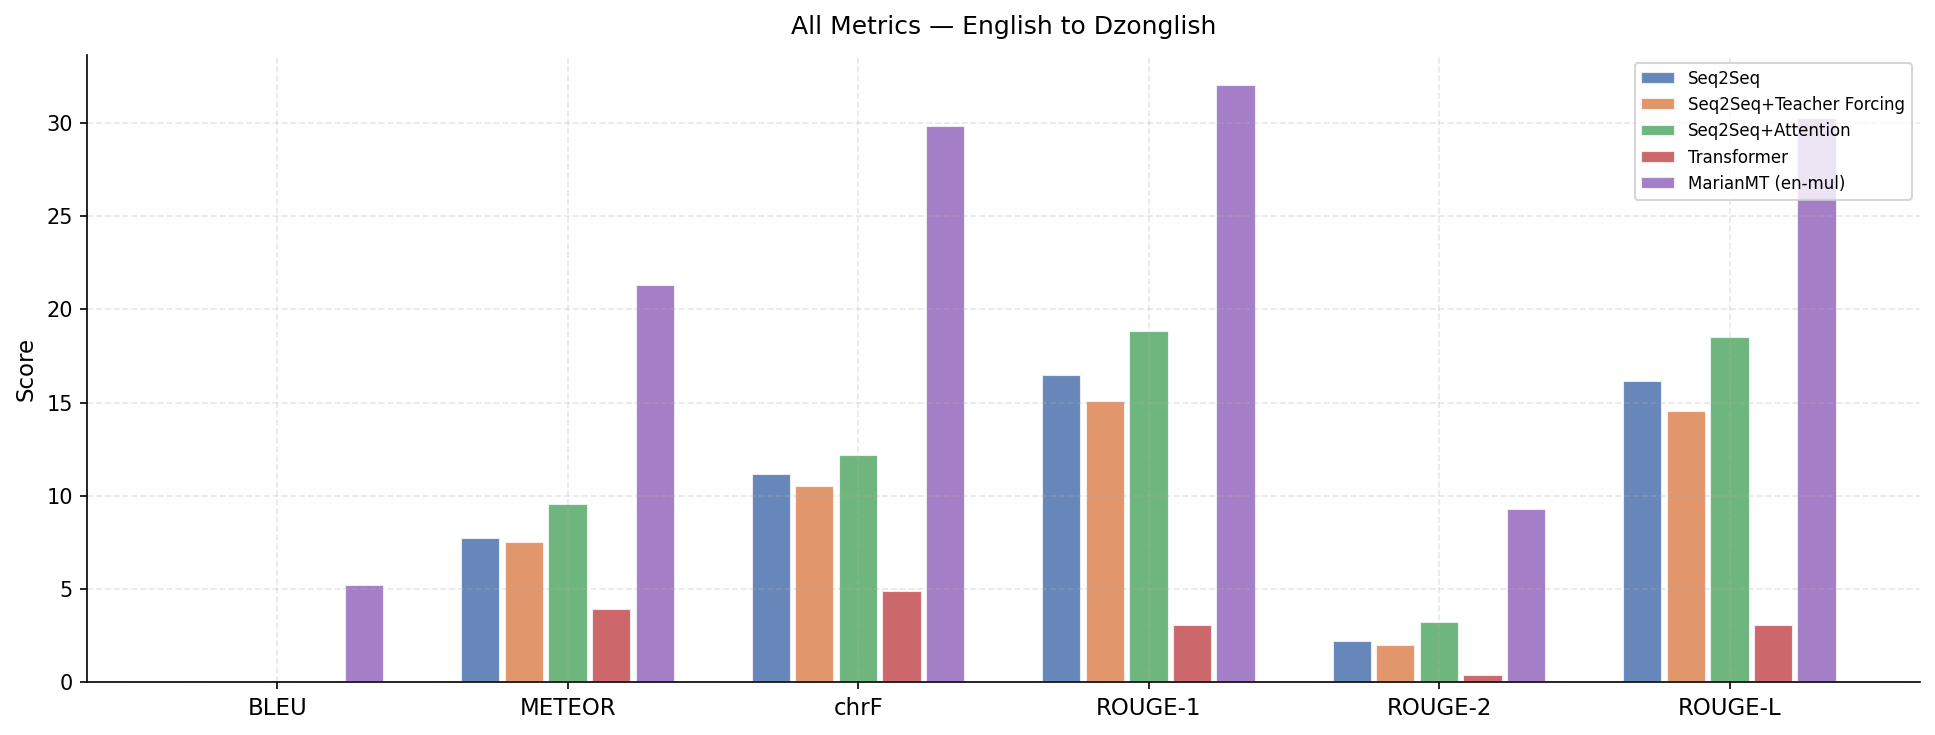

Saved: all_metrics_en_dz.png


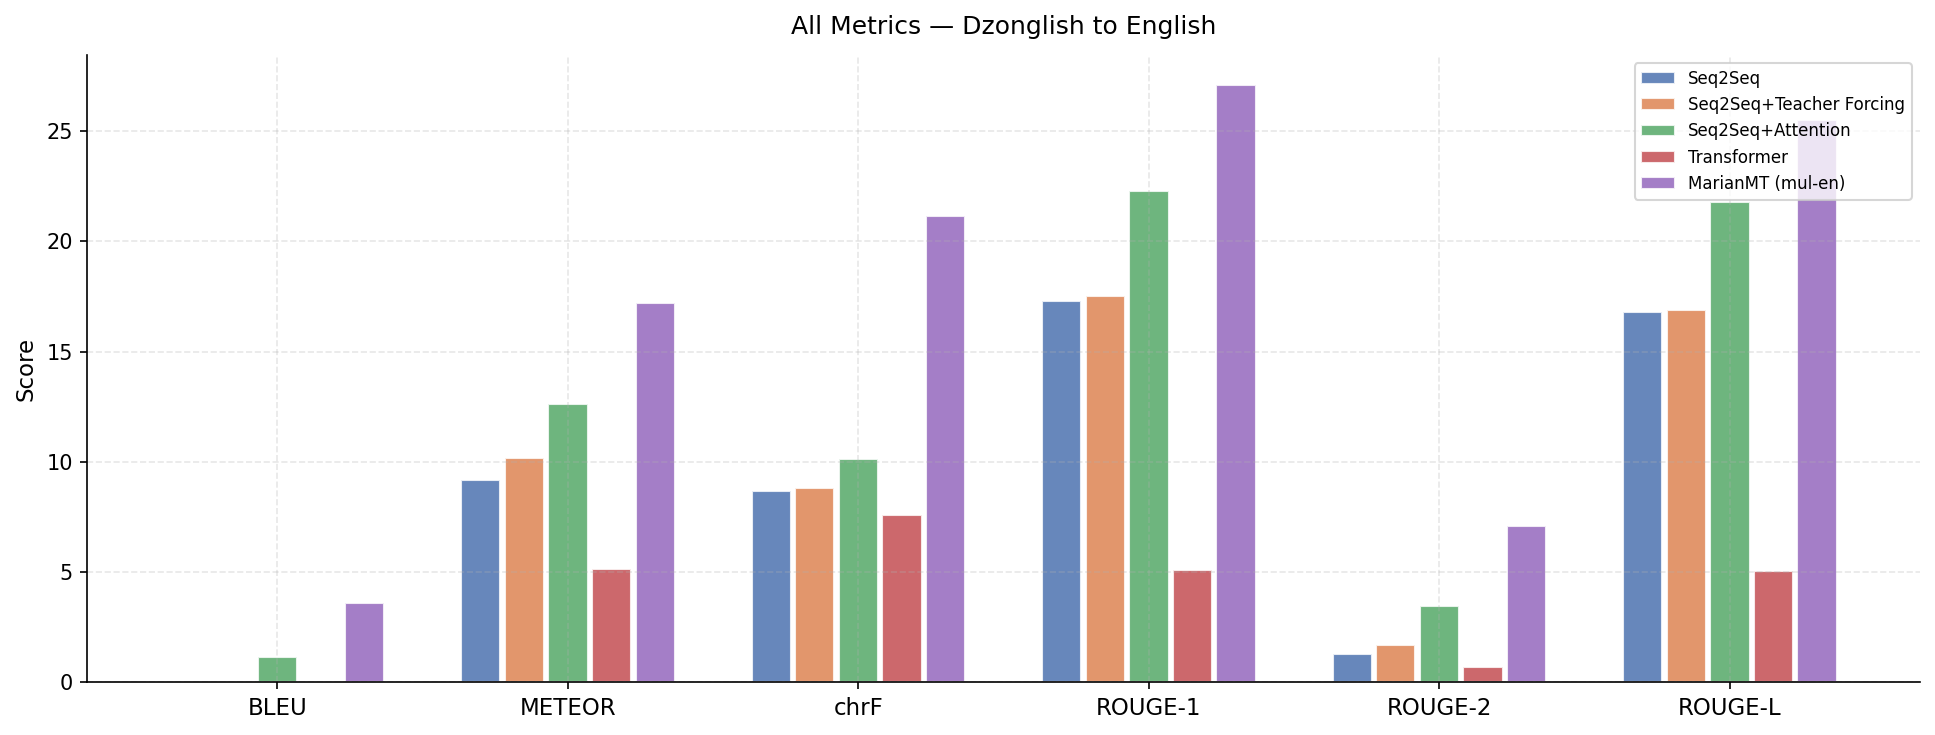

Saved: all_metrics_dz_en.png


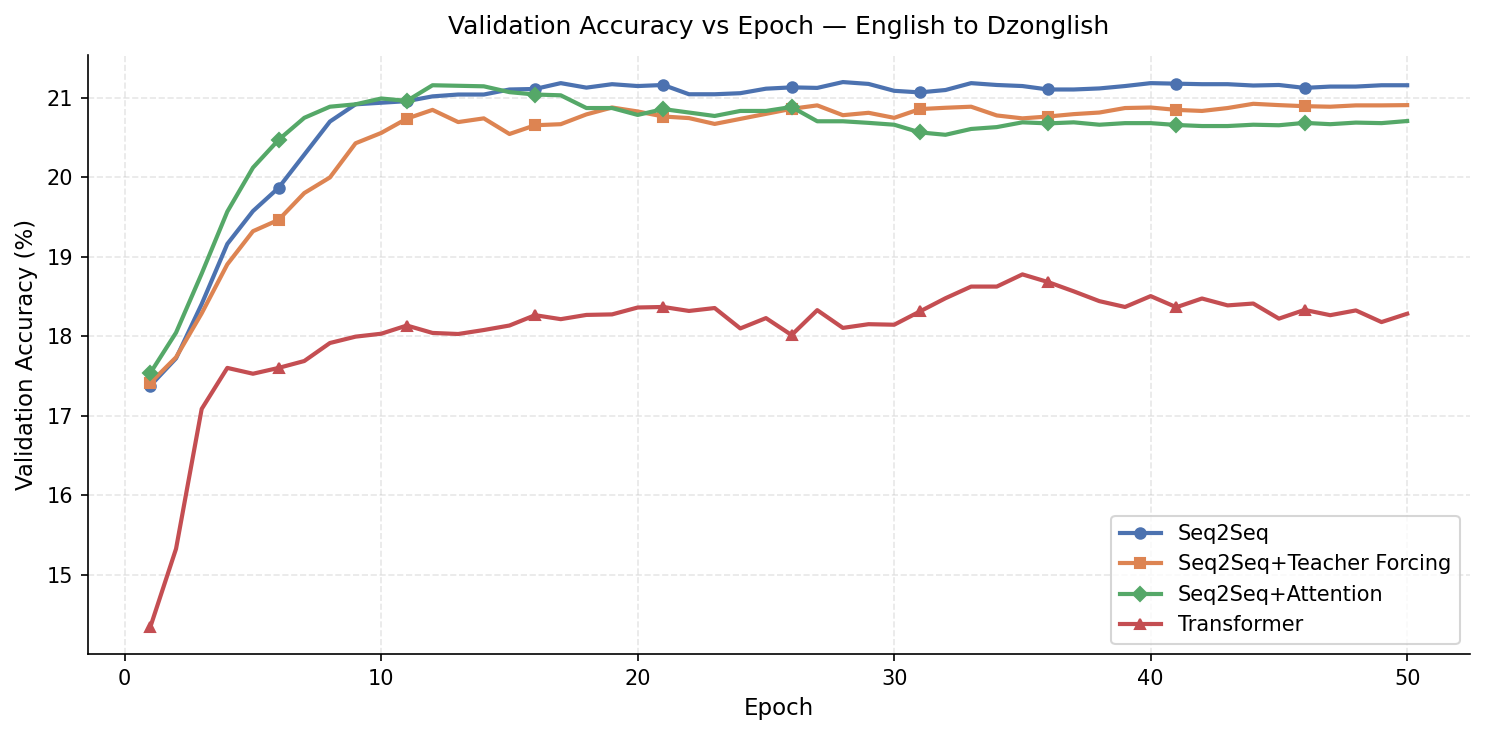

Saved: accuracy_curves_en_dz.png


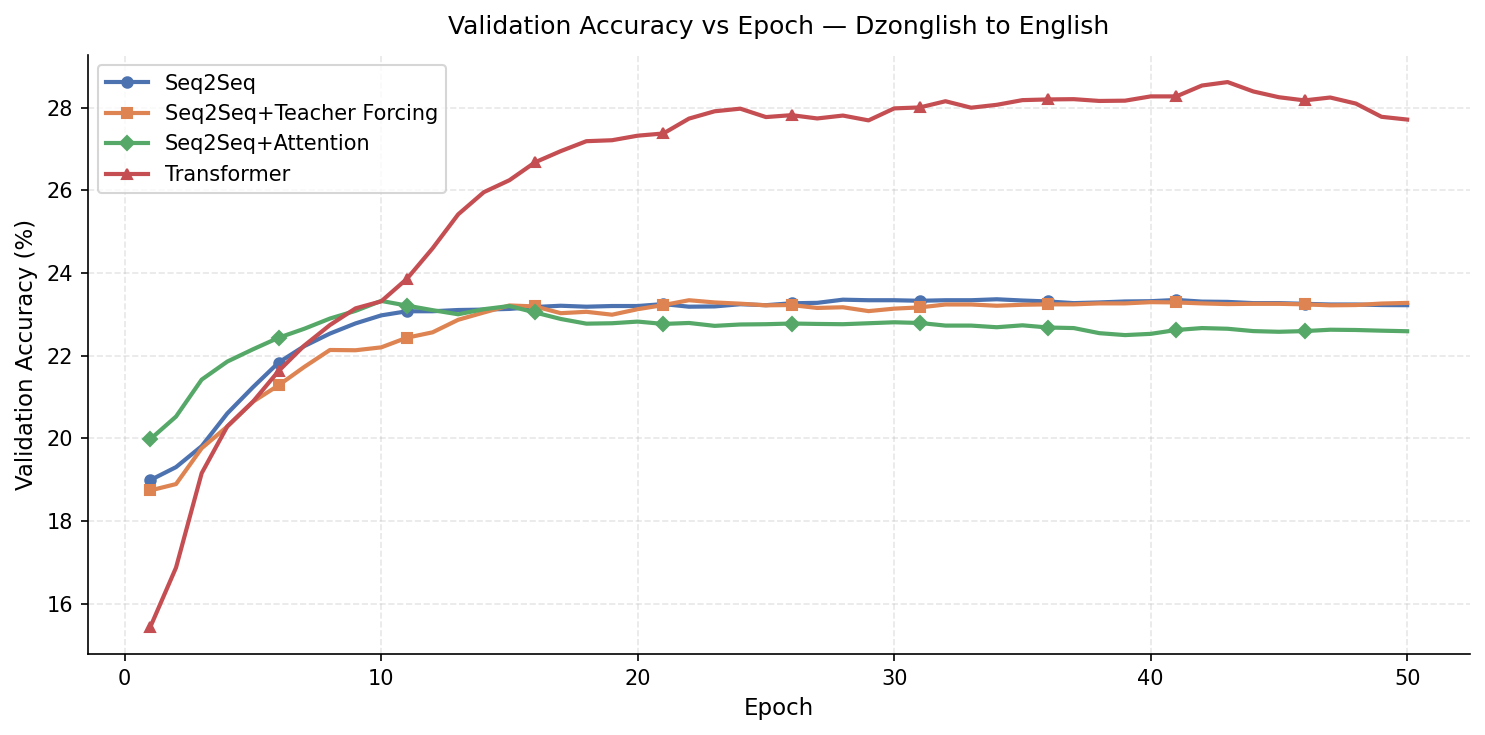

Saved: accuracy_curves_dz_en.png


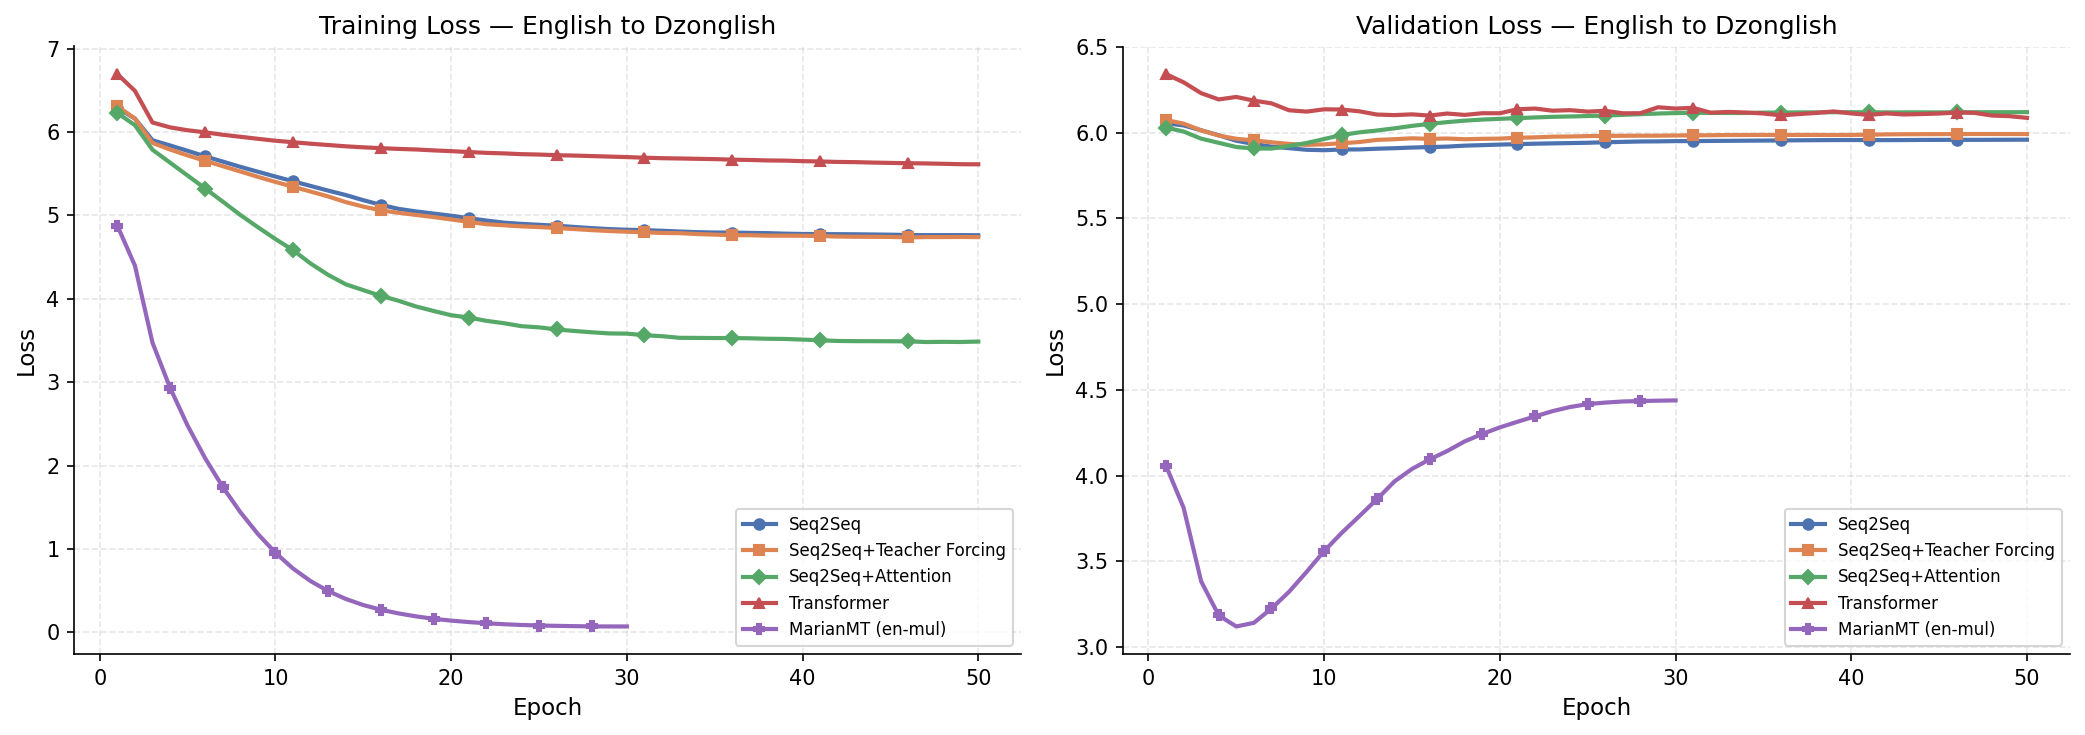

Saved: loss_curves_en_dz.png


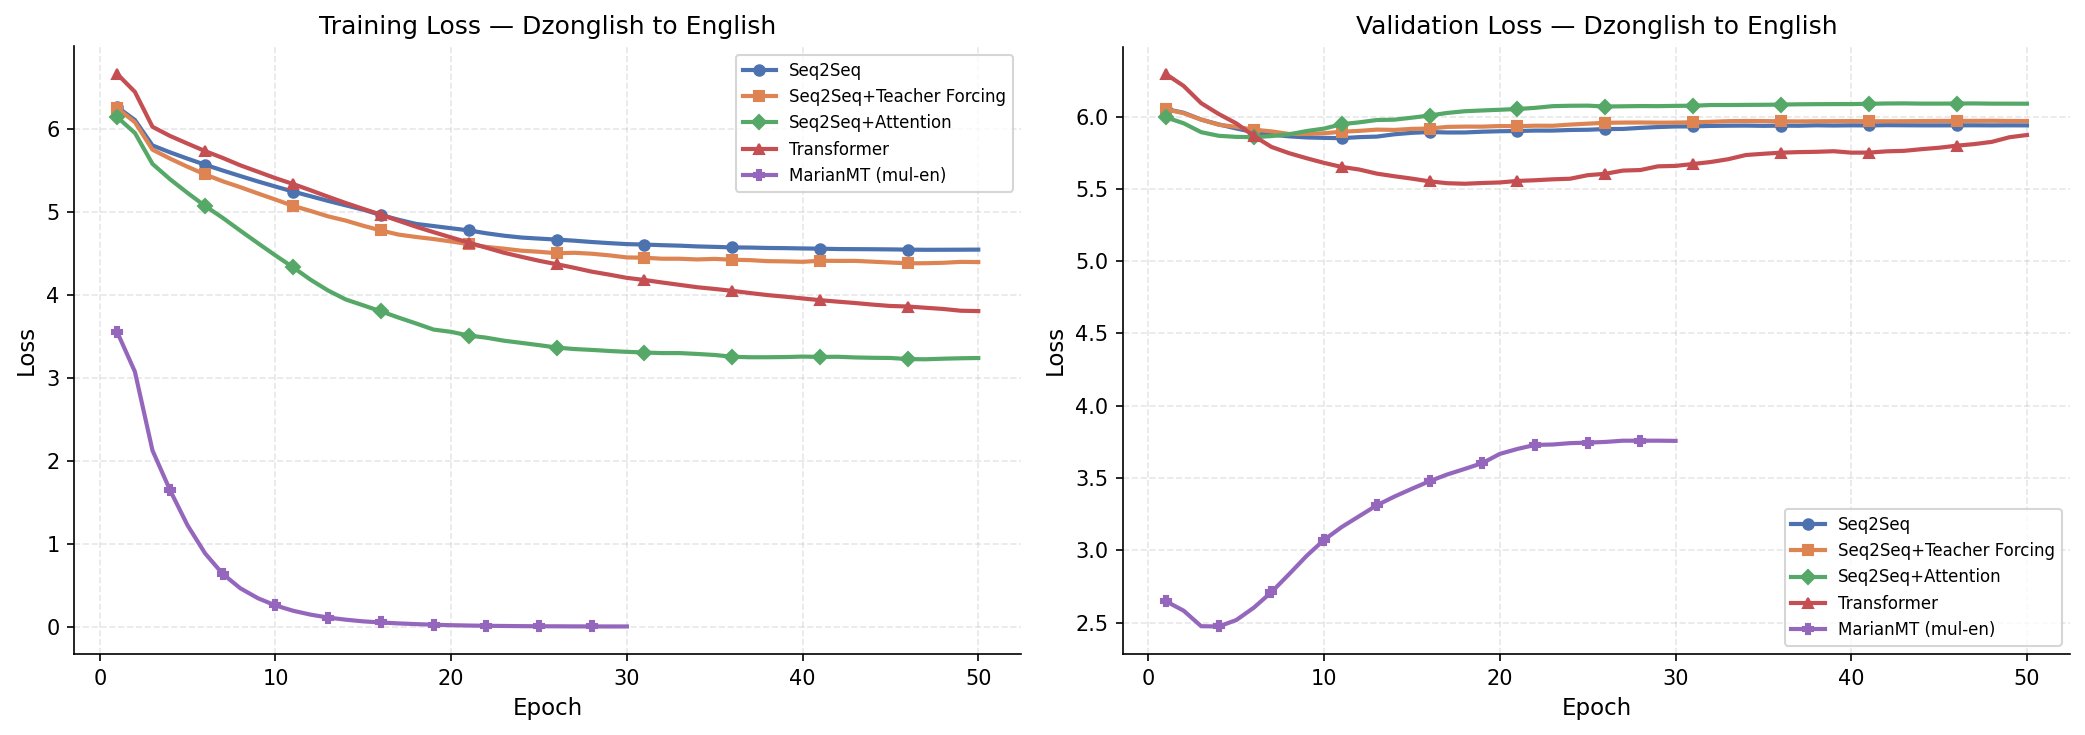

Saved: loss_curves_dz_en.png

All charts saved to /content/drive/MyDrive/NMT_Results

Send Claude:
  nmt_results.json
  bleu_all_models.png
  all_metrics_en_dz.png
  all_metrics_dz_en.png
  accuracy_curves_en_dz.png
  accuracy_curves_dz_en.png
  loss_curves_en_dz.png
  loss_curves_dz_en.png
  sentence_length_distribution.png
  Cell 16 text output


In [ ]:
# Cell 17: Generate all charts
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
    'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3,
    'grid.linestyle':'--','figure.dpi':150})

SCRATCH=['Seq2Seq','Seq2Seq+Teacher Forcing','Seq2Seq+Attention','Transformer']
COLS5  =['#4C72B0','#DD8452','#55A868','#C44E52','#9467BD']
MARKS  =['o','s','D','^','P']
DNS    =list(all_results.keys())
SFXS   =['en_dz','dz_en']
MKEYS  =['bleu','meteor','chrf','rouge1','rouge2','rougeL']
MLABS  =['BLEU','METEOR','chrF','ROUGE-1','ROUGE-2','ROUGE-L']

def sm(v,w=3): return [np.mean(v[max(0,i-w//2):min(len(v),i+w//2+1)]) for i in range(len(v))]

# Chart 1: BLEU all models both directions
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,dn in zip(axes,DNS):
    mods=list(all_results[dn].keys())
    bleus=[all_results[dn][m]['bleu'] for m in mods]
    short=[m.replace('Seq2Seq+','S2S+').replace('Seq2Seq','S2S').replace('MarianMT ','Marian\n') for m in mods]
    bars=ax.bar(short,bleus,color=COLS5[:len(mods)],alpha=0.85,edgecolor='white')
    for bar,val in zip(bars,bleus):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,
                f'{val:.2f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
    ax.set_ylabel('BLEU Score',fontsize=11); ax.set_title(f'BLEU — {dn}',fontsize=12,pad=10)
    ax.tick_params(axis='x',labelsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bleu_all_models.png',dpi=150,bbox_inches='tight')
plt.show(); print('Saved: bleu_all_models.png')

# Charts 2-3: All metrics grouped per direction
for dn,sfx in zip(DNS,SFXS):
    mods=list(all_results[dn].keys())
    fig,ax=plt.subplots(figsize=(13,5))
    x=np.arange(len(MKEYS)); w=0.15
    for j,(mn,c) in enumerate(zip(mods,COLS5)):
        vals=[all_results[dn][mn][k] for k in MKEYS]
        ax.bar(x+(j-len(mods)/2+0.5)*w,vals,w*0.9,label=mn,color=c,alpha=0.85,edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(MLABS,fontsize=11)
    ax.set_ylabel('Score',fontsize=11); ax.set_title(f'All Metrics — {dn}',fontsize=12,pad=10)
    ax.legend(fontsize=8,loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/all_metrics_{sfx}.png',dpi=150,bbox_inches='tight')
    plt.show(); print(f'Saved: all_metrics_{sfx}.png')

# Charts 4-5: Accuracy curves (scratch models only)
for dn,sfx in zip(DNS,SFXS):
    fig,ax=plt.subplots(figsize=(10,5))
    for mn,c,mk in zip(SCRATCH,COLS5,MARKS):
        if mn not in all_results[dn]: continue
        va=all_results[dn][mn]['val_acc']
        if not va: continue
        ax.plot(range(1,len(va)+1),sm(va),label=mn,color=c,
                marker=mk,markevery=max(1,len(va)//10),linewidth=2,markersize=5)
    ax.set_xlabel('Epoch',fontsize=11); ax.set_ylabel('Validation Accuracy (%)',fontsize=11)
    ax.set_title(f'Validation Accuracy vs Epoch — {dn}',fontsize=12,pad=10)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/accuracy_curves_{sfx}.png',dpi=150,bbox_inches='tight')
    plt.show(); print(f'Saved: accuracy_curves_{sfx}.png')

# Charts 6-7: Loss curves all models per direction
for dn,sfx in zip(DNS,SFXS):
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    for mn,c,mk in zip(list(all_results[dn].keys()),COLS5,MARKS):
        tl=all_results[dn][mn]['train_loss']; vl=all_results[dn][mn]['val_loss']
        if not tl: continue
        ep=range(1,len(tl)+1); mk2=max(1,len(tl)//10)
        axes[0].plot(ep,sm(tl),label=mn,color=c,marker=mk,markevery=mk2,linewidth=2,markersize=5)
        axes[1].plot(ep,sm(vl),label=mn,color=c,marker=mk,markevery=mk2,linewidth=2,markersize=5)
    for ax,title in zip(axes,['Training Loss','Validation Loss']):
        ax.set_xlabel('Epoch',fontsize=11); ax.set_ylabel('Loss',fontsize=11)
        ax.set_title(f'{title} — {dn}',fontsize=12); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/loss_curves_{sfx}.png',dpi=150,bbox_inches='tight')
    plt.show(); print(f'Saved: loss_curves_{sfx}.png')

print(f'\nAll charts saved to {OUTPUT_DIR}')
print('\nSend Claude:')
for f in ['nmt_results.json','bleu_all_models.png',
          'all_metrics_en_dz.png','all_metrics_dz_en.png',
          'accuracy_curves_en_dz.png','accuracy_curves_dz_en.png',
          'loss_curves_en_dz.png','loss_curves_dz_en.png',
          'sentence_length_distribution.png','Cell 16 text output']:
    print(f'  {f}')